# Resultados globales y por serie — Retail M5

Notebook para generar las figuras de resultados globales y por serie como imágenes únicas de 2 filas y 2 columnas.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# ============================================================
# Configuración visual común
# ============================================================

contextos = [728, 1092, 1456]

colors = {
    "Chronos-2": "#4C78A8",
    "TimeXer": "#F58518"
}

TITLE_PAD = 14  # distance between title and plot top edge (default matplotlib = 6)

plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   15,
    'axes.labelsize':   14,
    'xtick.labelsize':  13,
    'ytick.labelsize':  13,
    'legend.fontsize':  14,
    'figure.titlesize': 16,
    'axes.titlepad':    TITLE_PAD,
})

# Boosted sizes for multi-subplot figures (2+ panels per row)
MULTI_RC = {
    'axes.titlesize':   21,
    'axes.labelsize':   19,
    'xtick.labelsize':  17,
    'ytick.labelsize':  17,
    'legend.fontsize':  19,
    'axes.titlepad':    TITLE_PAD,
}

# ============================================================
# Resultados globales
# ============================================================

global_df = pd.DataFrame({
    "modelo": ["Chronos-2", "TimeXer", "Chronos-2", "TimeXer", "Chronos-2", "TimeXer"],
    "contexto": [728, 728, 1092, 1092, 1456, 1456],
    "MAE":  [1.9740, 1.9647, 1.9481, 1.9807, 1.9384, 1.9915],
    "RMSE": [3.5028, 3.5079, 3.4510, 3.4980, 3.4345, 3.5577],
    "MASE": [0.8444, 0.8353, 0.8333, 0.8383, 0.8294, 0.8370],
    "WQL":  [0.3571, 0.3585, 0.3552, 0.3582, 0.3526, 0.3633],
})

# ============================================================
# Resultados por serie
# ============================================================

series_summary = pd.DataFrame([
    {
        "modelo": "Chronos-2",
        "contexto": 728,
        "MAE_medio": 1.9740,
        "RMSE_medio": 2.6340,
        "MASE_medio": 0.8444,
        "WQL_medio": 0.4849,
        "series_MASE_lt_1_pct": 75.6
    },
    {
        "modelo": "Chronos-2",
        "contexto": 1092,
        "MAE_medio": 1.9481,
        "RMSE_medio": 2.6047,
        "MASE_medio": 0.8333,
        "WQL_medio": 0.4721,
        "series_MASE_lt_1_pct": 76.2
    },
    {
        "modelo": "Chronos-2",
        "contexto": 1456,
        "MAE_medio": 1.9384,
        "RMSE_medio": 2.5878,
        "MASE_medio": 0.8294,
        "WQL_medio": 0.4740,
        "series_MASE_lt_1_pct": 75.8
    },
    {
        "modelo": "TimeXer",
        "contexto": 728,
        "MAE_medio": 1.9647,
        "RMSE_medio": 2.6094,
        "MASE_medio": 0.8353,
        "WQL_medio": 0.5113,
        "series_MASE_lt_1_pct": 76.6
    },
    {
        "modelo": "TimeXer",
        "contexto": 1092,
        "MAE_medio": 1.9807,
        "RMSE_medio": 2.6052,
        "MASE_medio": 0.8383,
        "WQL_medio": 0.5295,
        "series_MASE_lt_1_pct": 77.0
    },
    {
        "modelo": "TimeXer",
        "contexto": 1456,
        "MAE_medio": 1.9915,
        "RMSE_medio": 2.6273,
        "MASE_medio": 0.8370,
        "WQL_medio": 0.5726,
        "series_MASE_lt_1_pct": 76.6
    },
])

In [28]:
def plot_metrics_2x2(
    data,
    metrics,
    ylabels,
    titles,
    filename,
    suptitle=None,
    decimals=None,
    legend_loc="lower center"
):
    """
    Genera dos figuras independientes 1×2 (una por fila) con las métricas indicadas.
    Cada subgráfica compara Chronos-2 y TimeXer para los tres contextos históricos.
    """

    if decimals is None:
        decimals = {}

    x = np.arange(len(contextos))
    width = 0.34

    for row_idx in range(2):
        row_slice = slice(row_idx * 2, (row_idx + 1) * 2)
        row_metrics = metrics[row_slice]
        row_ylabels = ylabels[row_slice]
        row_titles = titles[row_slice]

        with plt.rc_context(MULTI_RC):
            fig, axes = plt.subplots(1, 2, figsize=(17, 7))

            handles = None
            labels_leg = None

            for ax, metric, ylabel, title in zip(axes, row_metrics, row_ylabels, row_titles):
                pivot = (
                    data
                    .pivot(index="contexto", columns="modelo", values=metric)
                    .reindex(contextos)
                )

                bars_chronos = ax.bar(
                    x - width / 2,
                    pivot["Chronos-2"],
                    width=width,
                    label="Chronos-2",
                    color=colors["Chronos-2"],
                    edgecolor="black",
                    linewidth=0.8
                )

                bars_timexer = ax.bar(
                    x + width / 2,
                    pivot["TimeXer"],
                    width=width,
                    label="TimeXer",
                    color=colors["TimeXer"],
                    edgecolor="black",
                    linewidth=0.8
                )

                if handles is None:
                    handles, labels_leg = ax.get_legend_handles_labels()

                ymax = pivot.max().max() * 1.18
                ax.set_ylim(0, ymax)

                dec = decimals.get(metric, 3 if "MASE" in metric or "WQL" in metric else 1)

                for bars in (bars_chronos, bars_timexer):
                    for bar in bars:
                        value = bar.get_height()
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            value + ymax * 0.015,
                            f"{value:.{dec}f}",
                            ha="center",
                            va="bottom",
                            fontsize=14
                        )

                ax.set_title(title)
                ax.set_xlabel("Contexto histórico")
                ax.set_ylabel(ylabel)
                ax.set_xticks(x)
                ax.set_xticklabels([f"{c} días" for c in contextos])
                ax.grid(axis="y", linestyle="--", alpha=0.35)
                ax.set_axisbelow(True)

                if ax.get_legend() is not None:
                    ax.get_legend().remove()

            fig.legend(
                handles,
                labels_leg,
                title="Modelo",
                loc="lower center",
                ncol=2,
                frameon=True,
                bbox_to_anchor=(0.5, 0.06)
            )
            fig.tight_layout(rect=[0, 0.22, 1, 1])

            if filename:
                base = filename.rsplit(".", 1)[0] if "." in filename else filename
                fig.savefig(f"{base}_r{row_idx + 1}.png", dpi=300, bbox_inches="tight")

            plt.show()

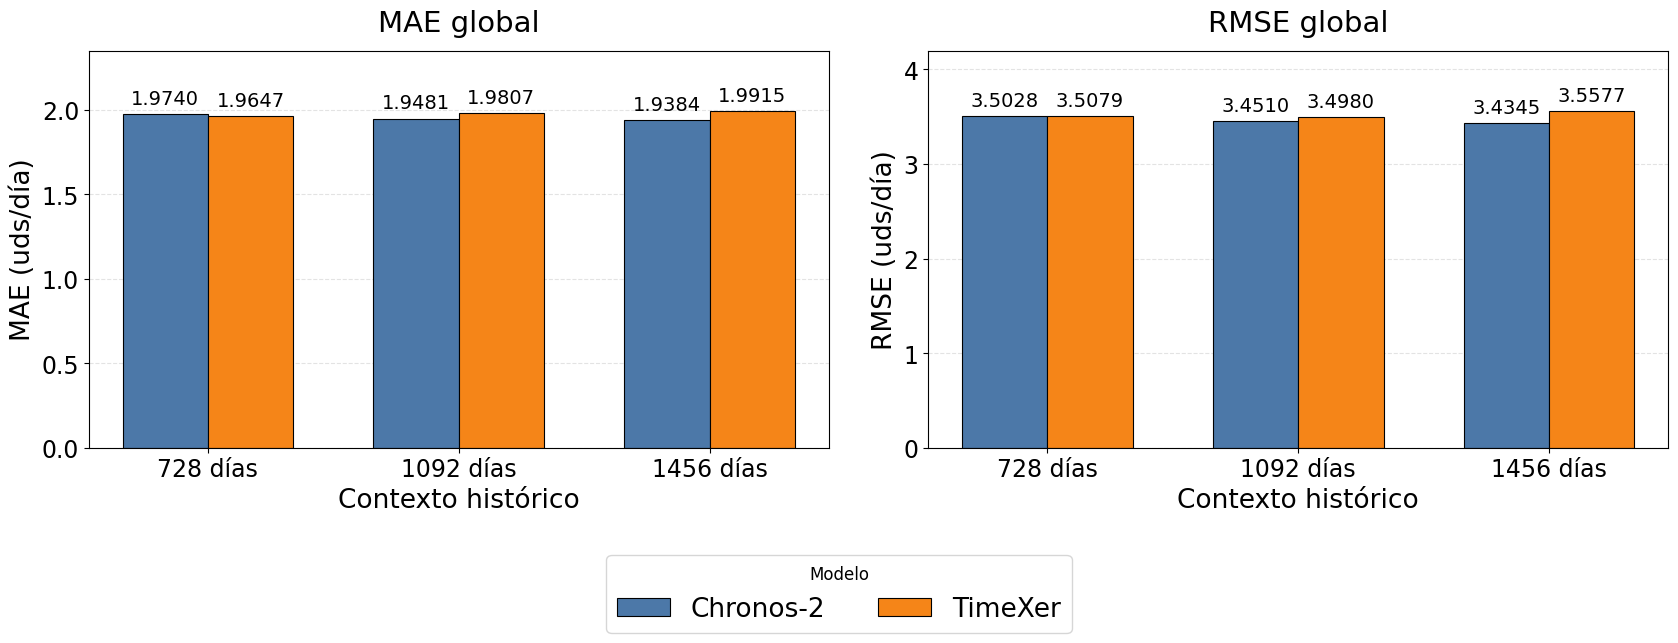

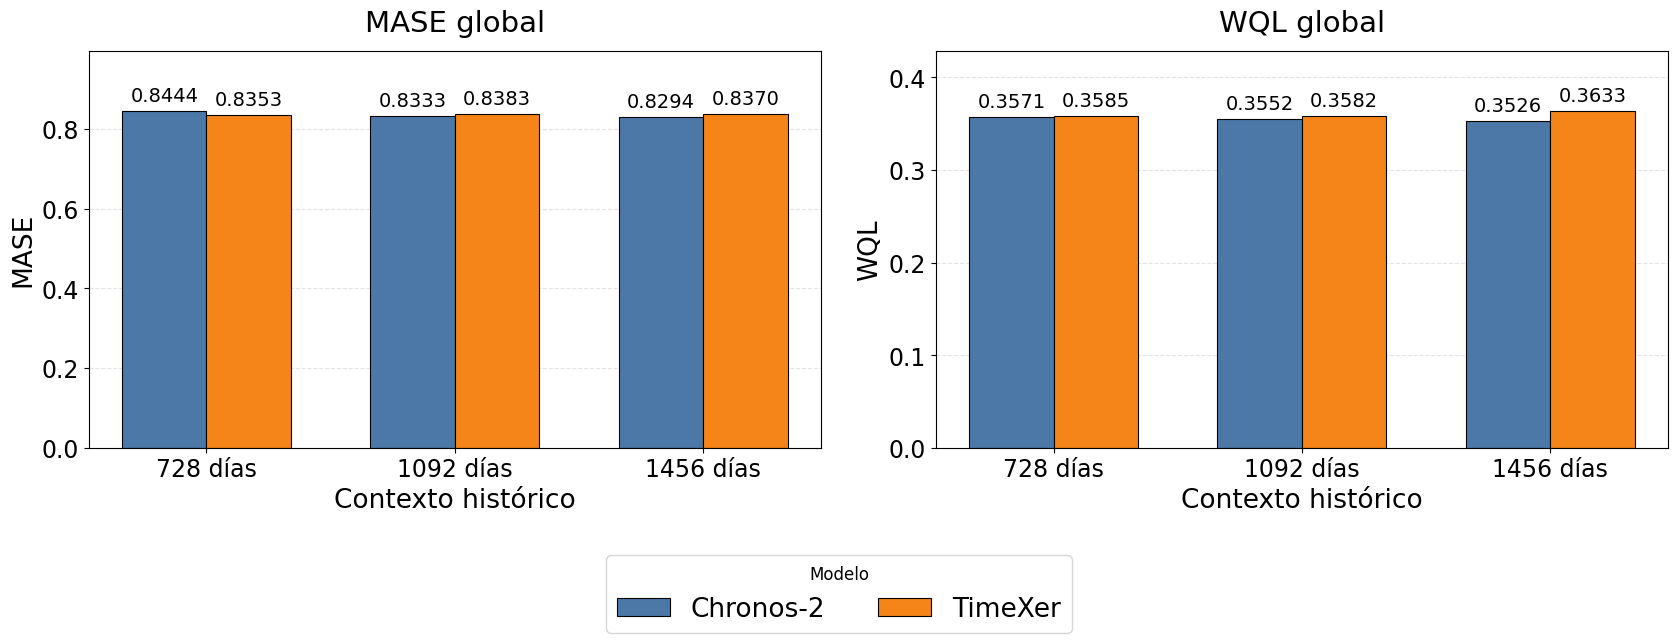

In [29]:
# ============================================================
# Figura 5.2.3: resultados globales en una única imagen 2x2
# ============================================================

plot_metrics_2x2(
    data=global_df,
    metrics=["MAE", "RMSE", "MASE", "WQL"],
    ylabels=[
        "MAE (uds/día)",
        "RMSE (uds/día)",
        "MASE",
        "WQL"
    ],
    titles=[
        "MAE global",
        "RMSE global",
        "MASE global",
        "WQL global"
    ],
    filename="fig_5_2_3_resultados_globales_retail_2x2.png",
    suptitle="Resultados globales por modelo y contexto — Retail M5",
    decimals={
        "MAE": 4,
        "RMSE": 4,
        "MASE": 4,
        "WQL": 4
    }
)

In [30]:
# ============================================================
# Tabla resumen simplificada para el apartado 5.2.4
# ============================================================

tabla_524 = series_summary.copy()

tabla_524["Contexto"] = tabla_524["contexto"].astype(str) + " días"
tabla_524["Series con MASE < 1"] = tabla_524["series_MASE_lt_1_pct"].map(lambda x: f"{x:.1f} %")

tabla_524 = tabla_524[[
    "modelo",
    "Contexto",
    "MAE_medio",
    "RMSE_medio",
    "MASE_medio",
    "WQL_medio",
    "Series con MASE < 1"
]]

tabla_524 = tabla_524.rename(columns={
    "modelo": "Modelo",
    "MAE_medio": "MAE medio por serie",
    "RMSE_medio": "RMSE medio por serie",
    "MASE_medio": "MASE medio por serie",
    "WQL_medio": "WQL medio por serie"
})

display(
    tabla_524.style.format({
        "MAE medio por serie": "{:.4f}",
        "RMSE medio por serie": "{:.4f}",
        "MASE medio por serie": "{:.4f}",
        "WQL medio por serie": "{:.4f}",
    })
)

,Modelo,Contexto,MAE medio por serie,RMSE medio por serie,MASE medio por serie,WQL medio por serie,Series con MASE < 1
0,Chronos-2,728 días,1.9740,2.6340,0.8444,0.4849,75.6 %
1,Chronos-2,1092 días,1.9481,2.6047,0.8333,0.4721,76.2 %
2,Chronos-2,1456 días,1.9384,2.5878,0.8294,0.4740,75.8 %
3,TimeXer,728 días,1.9647,2.6094,0.8353,0.5113,76.6 %
4,TimeXer,1092 días,1.9807,2.6052,0.8383,0.5295,77.0 %
5,TimeXer,1456 días,1.9915,2.6273,0.8370,0.5726,76.6 %


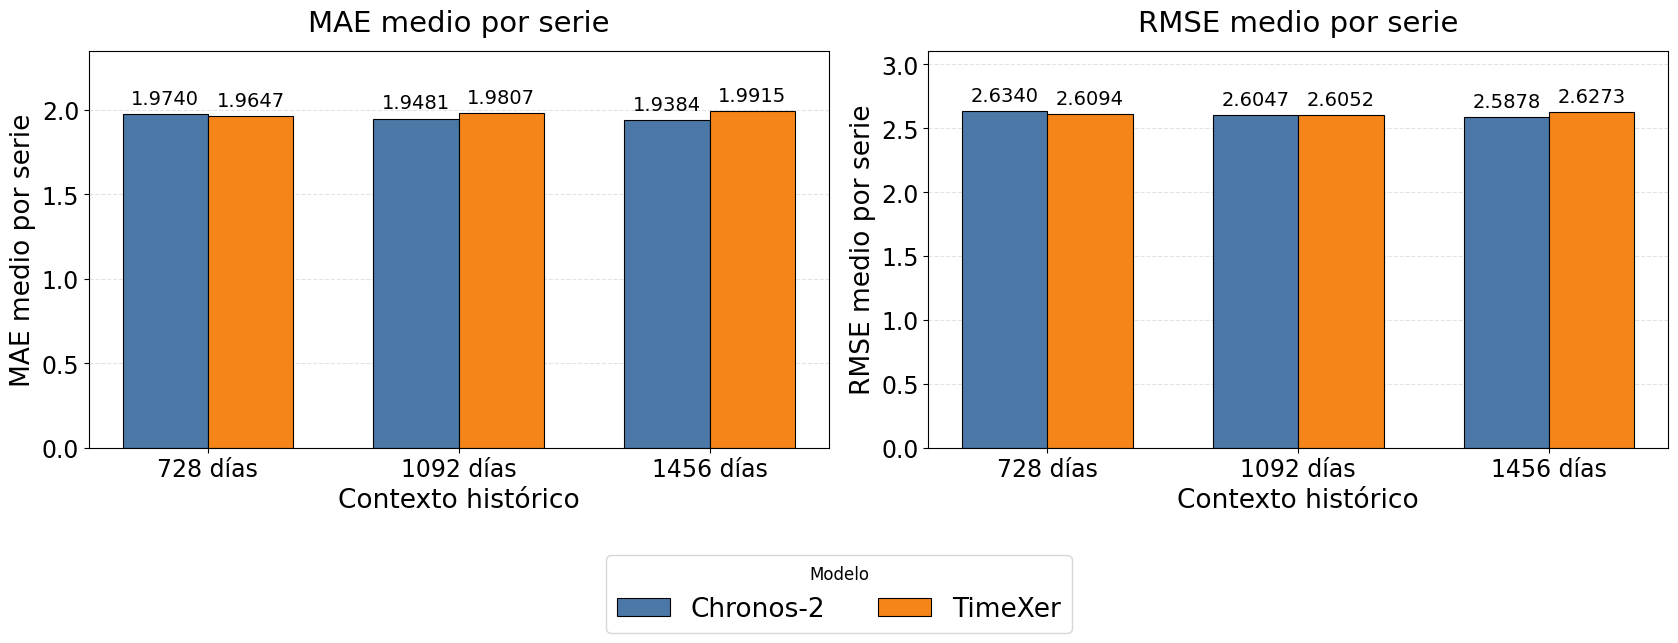

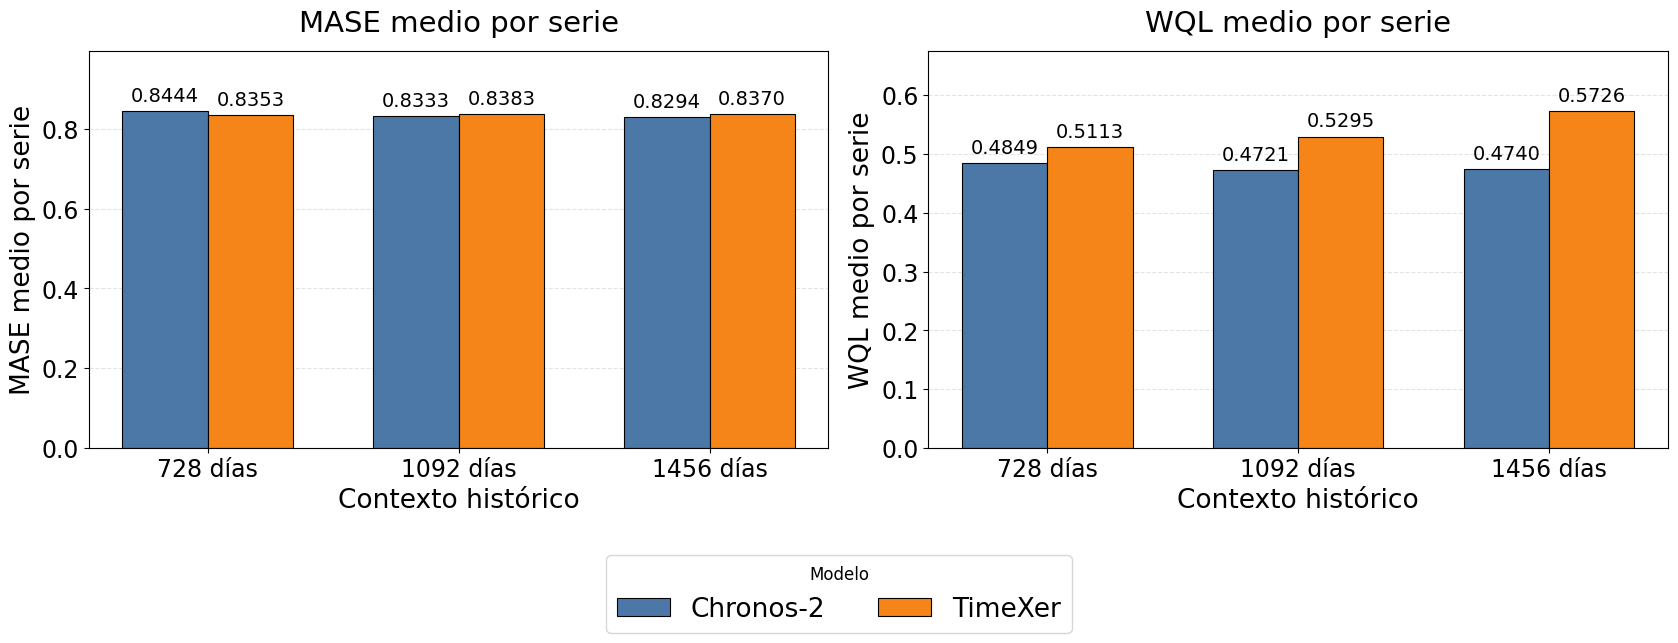

In [31]:
# ============================================================
# Figura 5.2.4: resultados por serie en una única imagen 2x2
# ============================================================

plot_metrics_2x2(
    data=series_summary,
    metrics=["MAE_medio", "RMSE_medio", "MASE_medio", "WQL_medio"],
    ylabels=[
        "MAE medio por serie",
        "RMSE medio por serie",
        "MASE medio por serie",
        "WQL medio por serie"
    ],
    titles=[
        "MAE medio por serie",
        "RMSE medio por serie",
        "MASE medio por serie",
        "WQL medio por serie"
    ],
    filename="fig_5_2_4_resultados_por_serie_retail_2x2.png",
    suptitle="Resultados por serie según modelo y contexto — Retail M5",
    decimals={
        "MAE_medio": 4,
        "RMSE_medio": 4,
        "MASE_medio": 4,
        "WQL_medio": 4
    }
)

,Modelo,Contexto,Tipo,Entrenamiento,Tiempo entrenamiento,Tiempo inferencia,MAE,RMSE,MASE,WQL
0,Chronos-2,1456 días,Fundacional zero-shot,No aplica,No aplica,24.30 s,1.9384,3.4345,0.8294,0.3526
1,TimeXer,728 días,Especialista supervisado,Sí,1 h 46 min 59 s,0.85 s,1.9647,3.5079,0.8353,0.3585


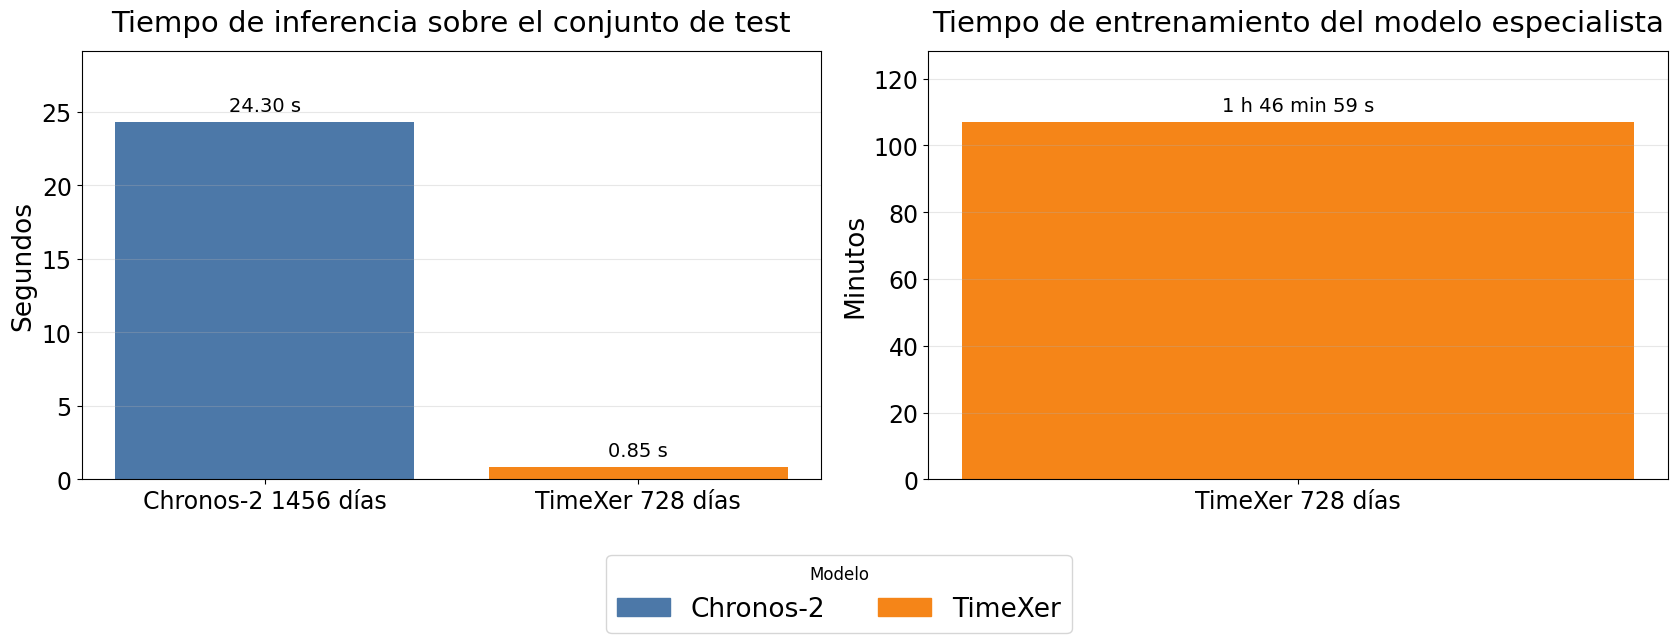

Resumen:
- Chronos-2 1456 días no requiere entrenamiento específico y tarda 24 s en inferencia.
- TimeXer 728 días requiere 1 h 46 min 59 s de entrenamiento y 1 s de inferencia.
- La inferencia de Chronos-2 es aproximadamente 28.7 veces más lenta que la de TimeXer en los escenarios finalistas.
- TimeXer, una vez entrenado, presenta una inferencia mucho más eficiente, aunque obtiene peor precisión global en los contextos más largos.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 5.2.6 Coste computacional — escenarios finalistas
# Finalistas: Chronos-2 1456 días (mejor MASE) vs TimeXer 728 días (mejor MASE TimeXer)
# ============================================================

def hms_to_seconds(hours=0, minutes=0, seconds=0):
    return hours * 3600 + minutes * 60 + seconds

def format_seconds(total_seconds):
    total_seconds = int(round(total_seconds))
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60
    if h > 0:
        return f"{h} h {m} min {s} s"
    if m > 0:
        return f"{m} min {s} s"
    return f"{s} s"

# Wall time from notebooks:
# Chronos-2 1456H inference: 24.3 s (from %%time output)
# TimeXer 728H training wall time: 1h 46min 59s
# TimeXer 728H inference wall time: 847 ms

data = [
    {
        "Modelo": "Chronos-2",
        "Contexto": "1456 días",
        "Tipo": "Fundacional zero-shot",
        "Entrenamiento": "No aplica",
        "Tiempo entrenamiento (s)": np.nan,
        "Tiempo inferencia (s)": 24.3,
        "MAE": 1.9384,
        "RMSE": 3.4345,
        "MASE": 0.8294,
        "WQL": 0.3526,
    },
    {
        "Modelo": "TimeXer",
        "Contexto": "728 días",
        "Tipo": "Especialista supervisado",
        "Entrenamiento": "Sí",
        "Tiempo entrenamiento (s)": hms_to_seconds(hours=1, minutes=46, seconds=59),
        "Tiempo inferencia (s)": 0.847,
        "MAE": 1.9647,
        "RMSE": 3.5079,
        "MASE": 0.8353,
        "WQL": 0.3585,
    },
]

df = pd.DataFrame(data)

df_table = df.copy()
df_table["Tiempo entrenamiento"] = df_table["Tiempo entrenamiento (s)"].apply(
    lambda x: "No aplica" if pd.isna(x) else format_seconds(x)
)
df_table["Tiempo inferencia"] = df_table["Tiempo inferencia (s)"].apply(
    lambda x: f"{x:.2f} s"
)

table_cols = [
    "Modelo",
    "Contexto",
    "Tipo",
    "Entrenamiento",
    "Tiempo entrenamiento",
    "Tiempo inferencia",
    "MAE",
    "RMSE",
    "MASE",
    "WQL",
]

display(df_table[table_cols])

df_table[table_cols].to_csv("tabla_coste_computacional_retail_finalistas.csv", index=False)

# ============================================================
# Figura: comparativa inferencia + entrenamiento (panel 1x2)
# ============================================================

labels = df["Modelo"] + " " + df["Contexto"]
bar_colors = [colors[m] for m in df["Modelo"]]

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))

    # Panel A: tiempo de inferencia
    values_infer = df["Tiempo inferencia (s)"]
    bars = axes[0].bar(labels, values_infer, color=bar_colors)
    axes[0].set_title("Tiempo de inferencia sobre el conjunto de test")
    axes[0].set_ylabel("Segundos")
    axes[0].set_xlabel("")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].set_ylim(0, max(values_infer) * 1.20)

    for bar, val in zip(bars, values_infer):
        height = bar.get_height()
        axes[0].annotate(
            f"{val:.2f} s",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

    # Panel B: tiempo de entrenamiento del modelo especialista
    timexer_train_s = df[df["Modelo"] == "TimeXer"].iloc[0]["Tiempo entrenamiento (s)"]
    timexer_train_min = timexer_train_s / 60

    bars2 = axes[1].bar(
        ["TimeXer 728 días"],
        [timexer_train_min],
        color=colors["TimeXer"]
    )
    axes[1].set_title("Tiempo de entrenamiento del modelo especialista")
    axes[1].set_ylabel("Minutos")
    axes[1].set_xlabel("")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].set_ylim(0, timexer_train_min * 1.20)

    axes[1].annotate(
        format_seconds(timexer_train_s),
        xy=(0, timexer_train_min),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["Chronos-2"]),
        plt.Rectangle((0, 0), 1, 1, color=colors["TimeXer"])
    ]

    fig.legend(
        legend_handles,
        ["Chronos-2", "TimeXer"],
        title="Modelo",
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.06)
    )

    fig.tight_layout(rect=[0, 0.22, 1, 1])
    plt.savefig("figura_coste_computacional_retail.png", dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# Resumen numérico
# ============================================================

chronos = df[df["Modelo"] == "Chronos-2"].iloc[0]
timexer = df[df["Modelo"] == "TimeXer"].iloc[0]

ratio_inference = chronos["Tiempo inferencia (s)"] / timexer["Tiempo inferencia (s)"]

print("Resumen:")
print(
    f"- Chronos-2 1456 días no requiere entrenamiento específico "
    f"y tarda {format_seconds(chronos['Tiempo inferencia (s)'])} en inferencia."
)
print(
    f"- TimeXer 728 días requiere {format_seconds(timexer['Tiempo entrenamiento (s)'])} "
    f"de entrenamiento y {format_seconds(timexer['Tiempo inferencia (s)'])} de inferencia."
)
print(
    f"- La inferencia de Chronos-2 es aproximadamente "
    f"{ratio_inference:.1f} veces más lenta que la de TimeXer en los escenarios finalistas."
)
print(
    "- TimeXer, una vez entrenado, presenta una inferencia mucho más eficiente, "
    "aunque obtiene peor precisión global en los contextos más largos."
)

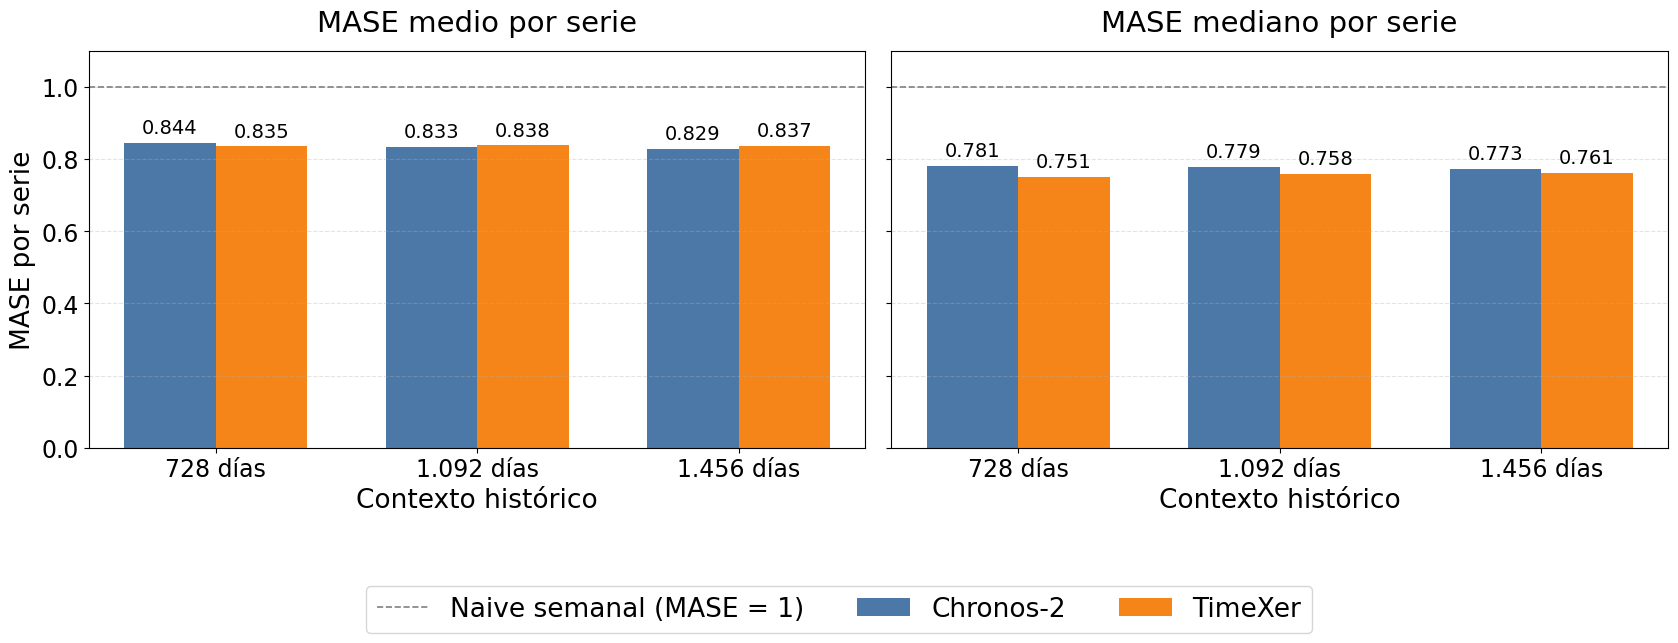

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figura 22 - MASE medio y mediano por serie en retail
# Colores por modelo: Chronos-2 azul, TimeXer naranja
# ============================================================

data = [
    {"modelo": "Chronos-2", "contexto": "728 días",   "mase_medio": 0.844, "mase_mediano": 0.781},
    {"modelo": "Chronos-2", "contexto": "1.092 días", "mase_medio": 0.833, "mase_mediano": 0.779},
    {"modelo": "Chronos-2", "contexto": "1.456 días", "mase_medio": 0.829, "mase_mediano": 0.773},
    {"modelo": "TimeXer",   "contexto": "728 días",   "mase_medio": 0.835, "mase_mediano": 0.751},
    {"modelo": "TimeXer",   "contexto": "1.092 días", "mase_medio": 0.838, "mase_mediano": 0.758},
    {"modelo": "TimeXer",   "contexto": "1.456 días", "mase_medio": 0.837, "mase_mediano": 0.761},
]

df = pd.DataFrame(data)

contextos_fig = ["728 días", "1.092 días", "1.456 días"]
x = np.arange(len(contextos_fig))
width = 0.35

chronos = df[df["modelo"] == "Chronos-2"].set_index("contexto").loc[contextos_fig]
timexer = df[df["modelo"] == "TimeXer"].set_index("contexto").loc[contextos_fig]

metricas = [
    ("mase_medio", "MASE medio por serie"),
    ("mase_mediano", "MASE mediano por serie"),
]

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(17, 7), sharey=True)

    for ax, (columna, titulo) in zip(axes, metricas):
        bars_chronos = ax.bar(
            x - width / 2,
            chronos[columna],
            width,
            label="Chronos-2",
            color=colors["Chronos-2"]
        )

        bars_timexer = ax.bar(
            x + width / 2,
            timexer[columna],
            width,
            label="TimeXer",
            color=colors["TimeXer"]
        )

        ax.axhline(
            y=1.0,
            linestyle="--",
            linewidth=1.2,
            color="gray",
            label="Naive semanal (MASE = 1)"
        )

        for bars in [bars_chronos, bars_timexer]:
            for bar in bars:
                height = bar.get_height()
                ax.annotate(
                    f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=14
                )

        ax.set_title(titulo)
        ax.set_xlabel("Contexto histórico")
        ax.set_xticks(x)
        ax.set_xticklabels(contextos_fig)
        ax.set_ylim(0, 1.10)
        ax.grid(axis="y", linestyle="--", alpha=0.35)

    axes[0].set_ylabel("MASE por serie")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles[:3],
        labels[:3],
        loc="lower center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.06)
    )

    fig.tight_layout(rect=[0, 0.22, 1, 1])

    plt.savefig(
        "fig22_mase_medio_mediano_por_serie_retail.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()